<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meu primeiro código em Python

Faça alguma descrição...

## Nada é bom

Algum  texto legal...

$a^2+b^2=c^2$


### Carregando um arquivo XLSX

Para carregar um arquivo `.xlsx`, você precisará primeiro fazer o upload para o ambiente do Colab (se ainda não o fez). Você pode arrastar e soltar o arquivo para a aba de arquivos à esquerda ou usar o seguinte código para fazer o upload:

# Arrumando a base de dados

In [2]:
import pandas as pd
df = pd.read_excel('dados_semana1.xlsx')

# 1. Reduzir o nome de cada variável para uma ou duas palavras.
new_column_names = {
    'Carimbo de data/hora': 'Data_Hora',
    'Nome ou apelido': 'Nome',
    'Curso': 'Curso',
    'Quantos cafés você consumiu nas últimas 24 horas?': 'Cafes_24h',
    'Qual é a temperatura ideal, em °C, para beber café filtrado?': 'Temp_Cafe',
    'Qual dessas frutas você prefere para suco natural?': 'Fruta_Suco',
    'Como você classificaria o nível de doçura ideal de um iogurte?': 'Docura_Iogurte',
    'Quantas refeições você faz por dia, em média?': 'Refeicoes_Dia',
    'Qual foi o peso, em gramas, da última porção de arroz que você consumiu?': 'Peso_Arroz_g',
    'Qual tipo de dieta você segue atualmente?': 'Tipo_Dieta',
    'Como você avalia sua preferência por alimentos crocantes?': 'Crocancia',
    'Quanto tempo, em minutos, você normalmente leva para preparar o café da manhã?': 'Tempo_Cafe_Manha'
}
df = df.rename(columns=new_column_names)

# Deletar as duas primeiras colunas (Data_Hora e Nome) e 'Curso'
columns_to_drop = ['Data_Hora', 'Nome', 'Curso']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
else:
    print(f"Warning: None of the intended columns to drop ({columns_to_drop}) were found in the DataFrame.")
    print(f"Current DataFrame columns: {df.columns.tolist()}")

# 2. Padronizar respostas das colunas, tirando números e textos das colunas.

# Function to extract numeric values from a series (e.g., '10 minutos' -> 10.0)
def extract_numeric(series):
    # Convert to string, replace comma with dot for decimals, then extract the first sequence of digits/decimals
    return series.astype(str).str.replace(',', '.').str.extract(r'(\d+\.?\d*)', expand=False).astype(float)

# Columns that are expected to be numerical but might contain text
numeric_cols_to_clean = [
    'Cafes_24h',
    'Temp_Cafe',
    'Refeicoes_Dia',
    'Peso_Arroz_g',
    'Tempo_Cafe_Manha'
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        # Apply extraction only if the column is of object type (contains strings/mixed types)
        if df[col].dtype == 'object':
            df[col] = extract_numeric(df[col])

# Columns that contain categorical text and need standardization (e.g., lowercasing, stripping whitespace)
categorical_cols_to_clean_text = [
    'Fruta_Suco',
    'Docura_Iogurte',
    'Tipo_Dieta'
]

for col in categorical_cols_to_clean_text:
    if col in df.columns:
        # Apply text cleaning only if the column is of object type
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.lower().str.strip()

# Transformar 'Cafes_24h' e 'Refeicoes_Dia' para int64
# Preencher NaN com 0 antes da conversão para int64
for col in ['Cafes_24h', 'Refeicoes_Dia']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype('int64')

# Transformar 'Docura_Iogurte' para categórica ordinal
if 'Docura_Iogurte' in df.columns:
    docura_order = ['baixo', 'médio', 'alto']
    # Certificar que todos os valores na coluna estão na ordem definida ou NaN
    df['Docura_Iogurte'] = pd.Categorical(df['Docura_Iogurte'], categories=docura_order, ordered=True)

# Transformar 'Crocancia' para categórica ordinal
if 'Crocancia' in df.columns:
    # Assumindo que Crocancia é uma escala numérica de 1 a 5 (ou similar)
    # Criar uma lista de categorias de 1 a 5
    crocancia_order = sorted(df['Crocancia'].unique().tolist())
    # Remover 0 se estiver presente e não for uma categoria válida
    if 0 in crocancia_order: crocancia_order.remove(0)
    df['Crocancia'] = pd.Categorical(df['Crocancia'], categories=crocancia_order, ordered=True)

# Display the first few rows of the cleaned DataFrame and its info to show changes
display(df.head())

Current DataFrame columns: ['Cafes_24h', 'Temp_Cafe', 'Fruta_Suco', 'Docura_Iogurte', 'Refeicoes_Dia', 'Peso_Arroz_g', 'Tipo_Dieta', 'Crocancia', 'Tempo_Cafe_Manha']


,Cafes_24h,Temp_Cafe,Fruta_Suco,Docura_Iogurte,Refeicoes_Dia,Peso_Arroz_g,Tipo_Dieta,Crocancia,Tempo_Cafe_Manha
0,0,0.0,manga,baixo,2,200.0,onívora,3,0.0
1,0,70.0,maracujá,médio,4,100.0,outra,3,30.0
2,0,40.0,laranja,médio,4,100.0,onívora,4,10.0
3,0,50.0,laranja,baixo,3,100.0,onívora,5,20.0
4,6,30.0,melancia,médio,5,70.0,onívora,5,30.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Cafes_24h         24 non-null     int64   
 1   Temp_Cafe         24 non-null     float64 
 2   Fruta_Suco        24 non-null     object  
 3   Docura_Iogurte    23 non-null     category
 4   Refeicoes_Dia     24 non-null     int64   
 5   Peso_Arroz_g      22 non-null     float64 
 6   Tipo_Dieta        24 non-null     object  
 7   Crocancia         24 non-null     category
 8   Tempo_Cafe_Manha  24 non-null     float64 
dtypes: category(2), float64(3), int64(2), object(2)
memory usage: 1.8+ KB


In [4]:
display(df.tail())

,Cafes_24h,Temp_Cafe,Fruta_Suco,Docura_Iogurte,Refeicoes_Dia,Peso_Arroz_g,Tipo_Dieta,Crocancia,Tempo_Cafe_Manha
19,0,50.0,laranja,médio,4,250.0,onívora,4,10.0
20,2,50.0,laranja,médio,3,300.0,onívora,4,2.0
21,0,35.0,laranja,médio,3,50.0,onívora,4,10.0
22,0,65.0,maracujá,baixo,3,80.0,onívora,1,20.0
23,1,65.0,laranja,médio,3,200.0,onívora,5,5.0


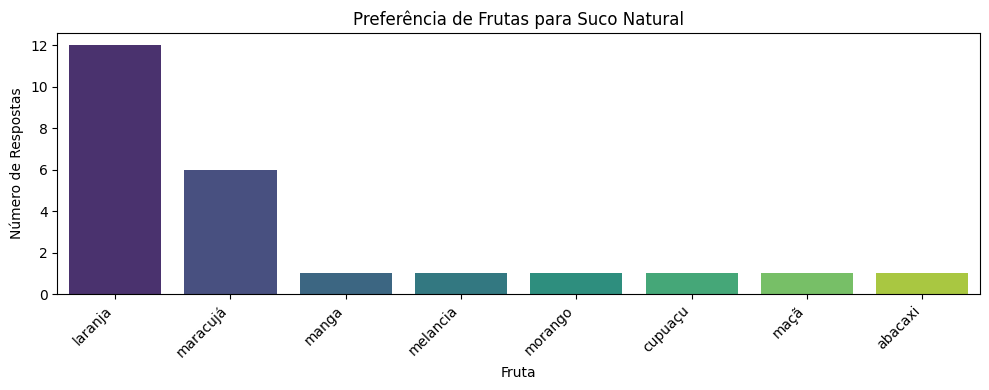

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defina o nome da coluna de interesse
column_name = "Fruta_Suco"

# Verifique se a coluna existe no DataFrame
if column_name in df.columns:
    # Conte a frequência de cada fruta
    fruit_counts = df[column_name].value_counts().reset_index()
    fruit_counts.columns = ['Fruta', 'Contagem']

    # Crie o gráfico de barras
    plt.figure(figsize=(10, 4))
    # Resolvendo o FutureWarning: usando hue='Fruta' e legend=False
    sns.barplot(x='Fruta', y='Contagem', data=fruit_counts, palette='viridis', hue='Fruta', legend=False)
    plt.title('Preferência de Frutas para Suco Natural')
    plt.xlabel('Fruta')
    plt.ylabel('Número de Respostas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"A coluna '{column_name}' não foi encontrada no DataFrame. Verifique o nome da coluna.")

# Tipos de variáveis

## Qual. nominal
- Exemplo 1
- Exemplo 2
- Exemplo 3

## Qual. ordinal
- Exemplo 1
- Exemplo 2
- Exemplo 3

## Quant. Discreta
- Exemplo 1
- Exemplo 2
- Exemplo 3

## Quant. Continua
- Exemplo 1
- Exemplo 2
- Exemplo 3


# Pergunta 1: O que é Estatística?

# Pergunta 2: Para que serve a Estatística?